# Minimal Burgers Discovery Story

This notebook is a deliberately bare-bones diagnostic. It uses the existing `burg_gen` dataset generator, the current `SirenMLP` surrogate, and the project's Burgers reference-derivative helper, but keeps the actual fitting, autodiff, least-squares identification, and minimal SymNet logic visible in notebook cells.

Questions answered in order:

1. What does the clean Burgers rollout look like?
2. Can the current SIREN fit the solution from data alone?
3. Do the fitted surrogate derivatives match the reference derivatives well enough?
4. Can direct least squares on surrogate derivatives recover Burgers?
5. What is the smallest visible SymNet-style product model that can express Burgers?
6. Does that architecture reproduce Burgers exactly when weights are hand-set?
7. If we start exactly at Burgers and train only SymNet, does it stay there or drift?
8. Optionally, what changes if SIREN and SymNet are trained jointly?

In [1]:
from __future__ import annotations

import copy
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from Datasets.data.processed.burg_gen.burg_gen import solve_burgers
from prog.mlps import SirenMLP
from utils.derivative_utils import build_burgers_reference_derivative_grids, compute_error_metrics

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")
print(f"seed = {SEED}")

device = cpu
seed = 0


mkdir -p failed for path /home/ghost/snap/codex/34/.config/matplotlib: [Errno 13] Permission denied: '/home/ghost/snap/codex/34/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-dlv6nbci because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def plot_time_slices(x, true_grid, pred_grid=None, time_values=None, title_prefix="u", slice_indices=None):
    if slice_indices is None:
        slice_indices = np.linspace(0, len(time_values) - 1, 5, dtype=int)
    ncols = len(slice_indices)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, slice_indices):
        ax.plot(x, true_grid[idx], label=f"true {title_prefix}", linewidth=2)
        if pred_grid is not None:
            ax.plot(x, pred_grid[idx], "--", label=f"pred {title_prefix}", linewidth=2)
        ax.set_title(f"t = {time_values[idx]:.3f}")
        ax.set_xlabel("x")
    axes[0].set_ylabel(title_prefix)
    axes[0].legend(loc="best")
    plt.tight_layout()
    plt.show()


def evaluate_model_and_derivatives_in_chunks(model, t_flat, x_flat, grid_shape, chunk_size=4096, device=device):
    u_parts = []
    ut_parts = []
    ux_parts = []
    uxx_parts = []

    model.eval()
    for start in range(0, len(t_flat), chunk_size):
        stop = min(start + chunk_size, len(t_flat))

        t_chunk = torch.tensor(t_flat[start:stop], dtype=torch.float32, device=device).reshape(-1, 1)
        x_chunk = torch.tensor(x_flat[start:stop], dtype=torch.float32, device=device).reshape(-1, 1)
        t_chunk.requires_grad_(True)
        x_chunk.requires_grad_(True)

        u_chunk = model(t_chunk, x_chunk)
        ut_chunk = torch.autograd.grad(
            u_chunk,
            t_chunk,
            grad_outputs=torch.ones_like(u_chunk),
            create_graph=False,
            retain_graph=True,
        )[0]
        ux_chunk = torch.autograd.grad(
            u_chunk,
            x_chunk,
            grad_outputs=torch.ones_like(u_chunk),
            create_graph=True,
            retain_graph=True,
        )[0]
        uxx_chunk = torch.autograd.grad(
            ux_chunk,
            x_chunk,
            grad_outputs=torch.ones_like(ux_chunk),
            create_graph=False,
            retain_graph=False,
        )[0]

        u_parts.append(u_chunk.detach().cpu().numpy())
        ut_parts.append(ut_chunk.detach().cpu().numpy())
        ux_parts.append(ux_chunk.detach().cpu().numpy())
        uxx_parts.append(uxx_chunk.detach().cpu().numpy())

    u = np.concatenate(u_parts, axis=0).reshape(grid_shape)
    ut = np.concatenate(ut_parts, axis=0).reshape(grid_shape)
    ux = np.concatenate(ux_parts, axis=0).reshape(grid_shape)
    uxx = np.concatenate(uxx_parts, axis=0).reshape(grid_shape)
    return {"u": u, "u_t": ut, "u_x": ux, "u_xx": uxx}


def as_metric_row(name, pred, ref):
    row = compute_error_metrics(pred, ref)
    row["quantity"] = name
    return row


def product_term_dict(model):
    left = model.left.weight.detach().cpu().numpy().reshape(-1)
    right = model.right.weight.detach().cpu().numpy().reshape(-1)
    linear = model.linear.weight.detach().cpu().numpy().reshape(-1)
    alpha = float(model.product_readout.weight.detach().cpu().numpy().reshape(-1)[0])
    names = ["u", "u_x", "u_xx"]

    coeffs = {
        "u": float(linear[0]),
        "u_x": float(linear[1]),
        "u_xx": float(linear[2]),
        "u^2": float(alpha * left[0] * right[0]),
        "u*u_x": float(alpha * (left[0] * right[1] + left[1] * right[0])),
        "u*u_xx": float(alpha * (left[0] * right[2] + left[2] * right[0])),
        "u_x^2": float(alpha * left[1] * right[1]),
        "u_x*u_xx": float(alpha * (left[1] * right[2] + left[2] * right[1])),
        "u_xx^2": float(alpha * left[2] * right[2]),
    }
    return coeffs


def pretty_equation(coeffs):
    ordered = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
    pieces = [f"({coeffs[name]:+.6f})*{name}" for name in ordered if abs(coeffs[name]) > 1e-12]
    return "u_t_hat = " + (" + ".join(pieces) if pieces else "0")


def initialize_symnet_to_burgers(model, diffusion=0.02):
    with torch.no_grad():
        model.left.weight.zero_()
        model.right.weight.zero_()
        model.linear.weight.zero_()
        model.product_readout.weight.zero_()

        model.left.weight[0, 0] = 1.0
        model.right.weight[0, 1] = 1.0
        model.product_readout.weight[0, 0] = -1.0
        model.linear.weight[0, 2] = diffusion


## 1. Load and Inspect the Burgers Data

Question answered here: what clean solution are we trying to fit, and what is the true PDE behind it?

In [3]:
NU_TRUE = 0.02

x_grid, _u_final, _t_end, (t_grid, u_grid) = solve_burgers(seed=SEED, return_history=True)
x_grid = np.asarray(x_grid, dtype=np.float32)
t_grid = np.asarray(t_grid, dtype=np.float32)
u_grid = np.asarray(u_grid, dtype=np.float32)

print(f"x shape: {x_grid.shape}")
print(f"t shape: {t_grid.shape}")
print(f"u shape: {u_grid.shape}")
print("true PDE: u_t = -u*u_x + 0.02*u_xx")

slice_indices = np.linspace(0, len(t_grid) - 1, 5, dtype=int)
slice_times = t_grid[slice_indices]
print("representative slice indices:", slice_indices)
print("representative slice times:", np.round(slice_times, 4))

x shape: (256,)
t shape: (252,)
u shape: (252, 256)
true PDE: u_t = -u*u_x + 0.02*u_xx
representative slice indices: [  0  62 125 188 251]
representative slice times: [0.    0.246 0.498 0.75  1.   ]


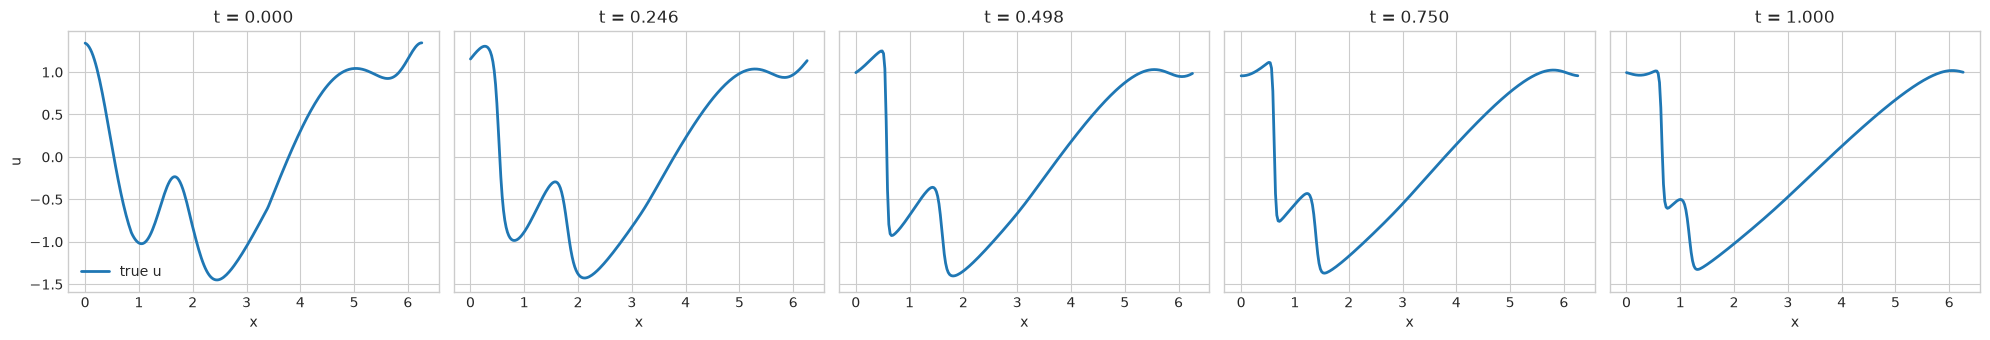

In [4]:
plot_time_slices(x_grid, u_grid, pred_grid=None, time_values=t_grid, title_prefix="u", slice_indices=slice_indices)

## 2. Fit the Neural Surrogate to Data Only

Question answered here: can the current SIREN represent the Burgers rollout when trained only on solution values, with no PDE loss or sparsity machinery?

In [5]:
T_mesh = np.repeat(t_grid[:, None], len(x_grid), axis=1)
X_mesh = np.repeat(x_grid[None, :], len(t_grid), axis=0)

t_flat = T_mesh.reshape(-1).astype(np.float32)
x_flat = X_mesh.reshape(-1).astype(np.float32)
u_flat = u_grid.reshape(-1).astype(np.float32)

t_train = torch.tensor(t_flat, dtype=torch.float32, device=device).reshape(-1, 1)
x_train = torch.tensor(x_flat, dtype=torch.float32, device=device).reshape(-1, 1)
u_train = torch.tensor(u_flat, dtype=torch.float32, device=device).reshape(-1, 1)

print("flattened training tensors:")
print("t_train", tuple(t_train.shape))
print("x_train", tuple(x_train.shape))
print("u_train", tuple(u_train.shape))

siren = SirenMLP(
    hidden_size=64,
    hidden_layers=3,
    first_omega_0=20.0,
    hidden_omega_0=1.0,
).to(device)

adam_steps = 2500
lbfgs_steps = 200
batch_size = 4096
log_every = 250

adam = torch.optim.Adam(siren.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
data_history = []

for step in range(1, adam_steps + 1):
    idx = torch.randint(0, len(t_train), (batch_size,), device=device)
    t_batch = t_train[idx]
    x_batch = x_train[idx]
    u_batch = u_train[idx]

    pred_batch = siren(t_batch, x_batch)
    loss = loss_fn(pred_batch, u_batch)

    adam.zero_grad()
    loss.backward()
    adam.step()

    if step % log_every == 0 or step == 1:
        with torch.no_grad():
            full_loss = loss_fn(siren(t_train, x_train), u_train).item()
        data_history.append({"stage": "adam", "step": step, "loss": full_loss})
        print(f"adam step {step:4d} | full data MSE = {full_loss:.6e}")

lbfgs = torch.optim.LBFGS(siren.parameters(), lr=1.0, max_iter=lbfgs_steps, history_size=50, line_search_fn="strong_wolfe")

def lbfgs_closure():
    lbfgs.zero_grad()
    pred = siren(t_train, x_train)
    loss = loss_fn(pred, u_train)
    loss.backward()
    return loss

lbfgs_loss = float(lbfgs.step(lbfgs_closure))
with torch.no_grad():
    final_data_mse = loss_fn(siren(t_train, x_train), u_train).item()
print(f"lbfgs start loss = {lbfgs_loss:.6e}")
print(f"final full data MSE = {final_data_mse:.6e}")

flattened training tensors:
t_train (64512, 1)
x_train (64512, 1)
u_train (64512, 1)
adam step    1 | full data MSE = 1.237509e+00
adam step  250 | full data MSE = 2.239449e-03
adam step  500 | full data MSE = 9.205454e-04
adam step  750 | full data MSE = 5.343718e-04
adam step 1000 | full data MSE = 3.489708e-04
adam step 1250 | full data MSE = 2.460817e-04
adam step 1500 | full data MSE = 1.849820e-04
adam step 1750 | full data MSE = 1.402480e-04
adam step 2000 | full data MSE = 1.112314e-04
adam step 2250 | full data MSE = 8.973129e-05
adam step 2500 | full data MSE = 7.444458e-05
lbfgs start loss = 7.444458e-05
final full data MSE = 5.603033e-05


burgers_minimal_discovery_story.ipynb:cell_5:61: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)


,mse,rel_l2,rmse,max_abs
quantity,,,,
u,0.000056,0.008739,0.007485,0.067407


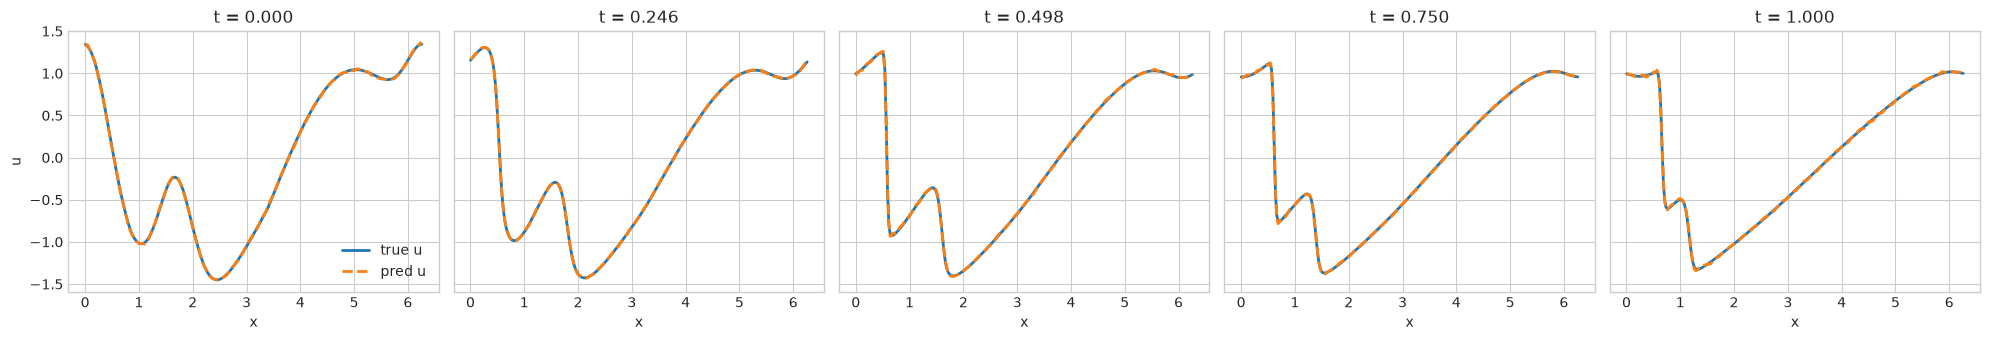

In [6]:
with torch.no_grad():
    u_pred_grid = siren(t_train, x_train).detach().cpu().numpy().reshape(u_grid.shape)

solution_metrics = pd.DataFrame([
    as_metric_row("u", u_pred_grid, u_grid),
]).set_index("quantity")
display(solution_metrics)

plot_time_slices(x_grid, u_grid, pred_grid=u_pred_grid, time_values=t_grid, title_prefix="u", slice_indices=slice_indices)

## 3. Inspect Derivatives Produced by the Fitted Surrogate

Question answered here: after fitting only to solution values, do the surrogate's autodiff derivatives `u_t`, `u_x`, and `u_xx` match the clean Burgers reference derivatives used elsewhere in the project?

In [7]:
reference = build_burgers_reference_derivative_grids(
    u_grid=u_grid,
    x_grid=x_grid,
    nu=NU_TRUE,
)

surrogate_fields = evaluate_model_and_derivatives_in_chunks(
    siren,
    t_flat=t_flat,
    x_flat=x_flat,
    grid_shape=u_grid.shape,
    chunk_size=4096,
    device=device,
)

derivative_metrics = pd.DataFrame([
    as_metric_row("u_t", surrogate_fields["u_t"], reference["u_t"]["physical"]),
    as_metric_row("u_x", surrogate_fields["u_x"], reference["u_x"]["physical"]),
    as_metric_row("u_xx", surrogate_fields["u_xx"], reference["u_xx"]["physical"]),
]).set_index("quantity")
display(derivative_metrics)

,mse,rel_l2,rmse,max_abs
quantity,,,,
u_t,0.035534,0.193228,0.188504,1.646756
u_x,0.076159,0.118011,0.275970,2.759550
u_xx,265.762839,0.321211,16.302234,213.587278


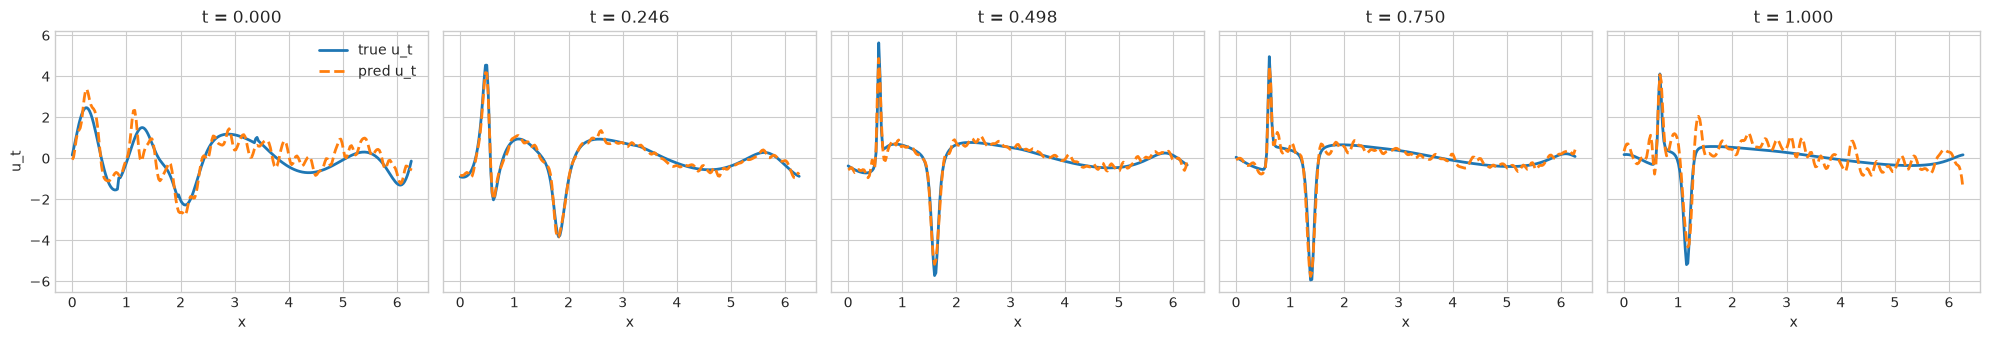

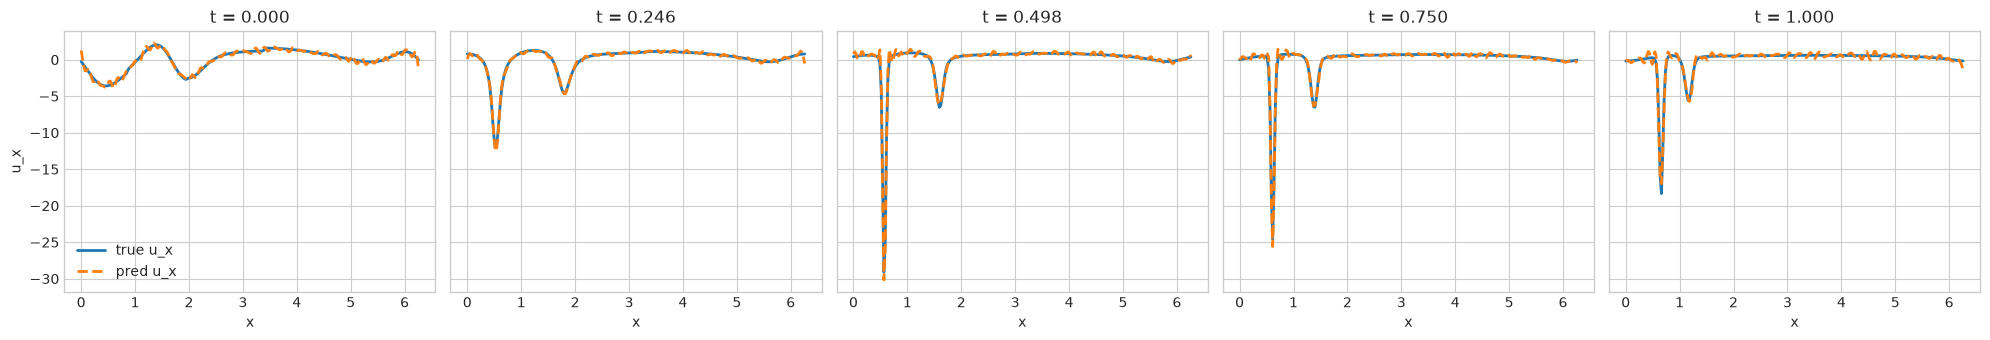

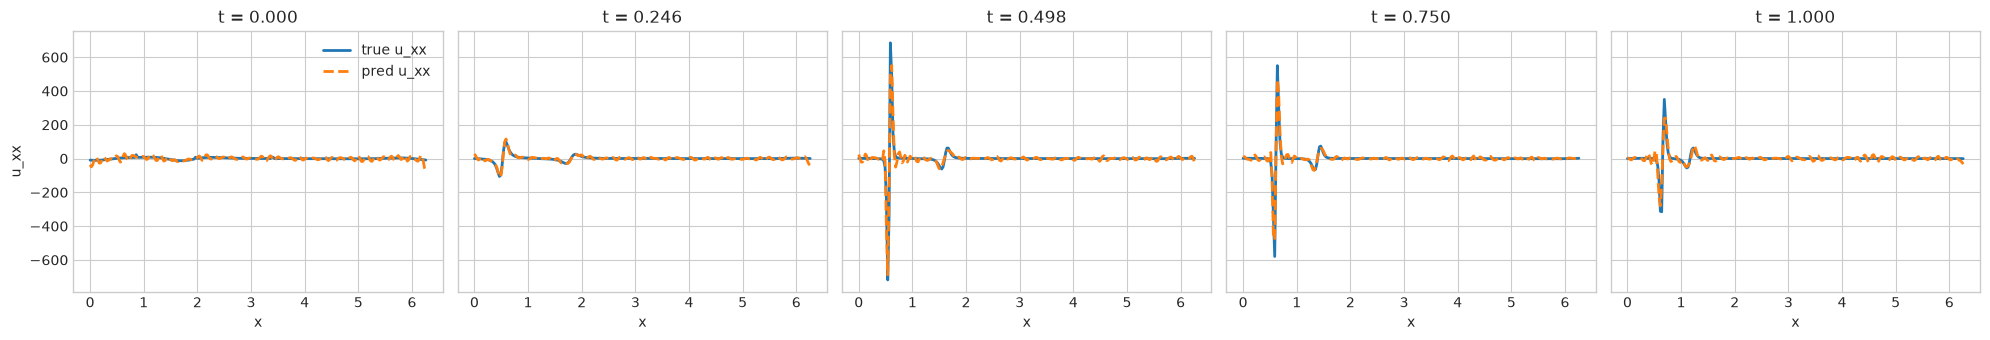

In [8]:
for quantity, ref_key in [("u_t", "u_t"), ("u_x", "u_x"), ("u_xx", "u_xx")]:
    plot_time_slices(
        x_grid,
        reference[ref_key]["physical"],
        pred_grid=surrogate_fields[quantity],
        time_values=t_grid,
        title_prefix=quantity,
        slice_indices=slice_indices,
    )

## 4. Recover Burgers with Direct Least Squares

Question answered here: if we freeze the surrogate and use only the Burgers basis `[u*u_x, u_xx]`, do the surrogate derivatives contain enough information for ordinary least squares to recover `u_t = -u*u_x + 0.02*u_xx`?

In [9]:
theta = np.column_stack([
    (surrogate_fields["u"] * surrogate_fields["u_x"]).reshape(-1),
    surrogate_fields["u_xx"].reshape(-1),
])
y = surrogate_fields["u_t"].reshape(-1)

coeffs_ls, residuals_ls, rank_ls, singular_vals_ls = np.linalg.lstsq(theta, y, rcond=None)
ls_prediction = (theta @ coeffs_ls).reshape(u_grid.shape)
ls_residual_norm = float(np.linalg.norm(y - theta @ coeffs_ls))

print(f"rank(theta) = {rank_ls}")
print(f"singular values = {singular_vals_ls}")
print(f"least-squares residual L2 norm = {ls_residual_norm:.6e}")
print()
print(f"Recovered PDE: u_t = ({coeffs_ls[0]:+.6f}) * u*u_x + ({coeffs_ls[1]:+.6f}) * u_xx")
print(f"Compare c1 against -1.00  -> error = {coeffs_ls[0] + 1.0:+.6e}")
print(f"Compare c2 against +0.02 -> error = {coeffs_ls[1] - 0.02:+.6e}")

display(pd.DataFrame([
    {"coefficient": "u*u_x", "recovered": coeffs_ls[0], "truth": -1.0, "error": coeffs_ls[0] + 1.0},
    {"coefficient": "u_xx", "recovered": coeffs_ls[1], "truth": 0.02, "error": coeffs_ls[1] - 0.02},
]).set_index("coefficient"))

display(pd.DataFrame([
    as_metric_row("LS RHS vs surrogate u_t", ls_prediction, surrogate_fields["u_t"]),
]).set_index("quantity"))

rank(theta) = 2
singular values = [12545.342     269.15878]
least-squares residual L2 norm = 9.797658e+01

Recovered PDE: u_t = (-0.849441) * u*u_x + (+0.016593) * u_xx
Compare c1 against -1.00  -> error = +1.505594e-01
Compare c2 against +0.02 -> error = -3.406685e-03


,recovered,truth,error
coefficient,,,
u*u_x,-0.849441,-1.00,0.150559
u_xx,0.016593,0.02,-0.003407


,mse,rel_l2,rmse,max_abs
quantity,,,,
LS RHS vs surrogate u_t,0.1488,0.39375,0.385747,4.152788


## 5. Define a Minimal SymNet/EQL Model Directly in the Notebook

Question answered here: what is the smallest visible one-product architecture that can represent the Burgers right-hand side from inputs `[u, u_x, u_xx]`?

In [10]:
class MinimalSymNet(nn.Module):
    """
    Three primitive inputs: [u, u_x, u_xx]
    One product channel: (left(features)) * (right(features))
    Final readout: linear primitive term + weighted product term
    """

    def __init__(self):
        super().__init__()
        self.left = nn.Linear(3, 1, bias=False)
        self.right = nn.Linear(3, 1, bias=False)
        self.linear = nn.Linear(3, 1, bias=False)
        self.product_readout = nn.Linear(1, 1, bias=False)

    def forward(self, features):
        z_left = self.left(features)
        z_right = self.right(features)
        product = z_left * z_right
        linear_part = self.linear(features)
        return linear_part + self.product_readout(product)


symnet_demo = MinimalSymNet()
print(symnet_demo)
print()
print("forward map:")
print("z_left  = left([u, u_x, u_xx])")
print("z_right = right([u, u_x, u_xx])")
print("product = z_left * z_right")
print("output  = linear([u, u_x, u_xx]) + product_readout(product)")

MinimalSymNet(
  (left): Linear(in_features=3, out_features=1, bias=False)
  (right): Linear(in_features=3, out_features=1, bias=False)
  (linear): Linear(in_features=3, out_features=1, bias=False)
  (product_readout): Linear(in_features=1, out_features=1, bias=False)
)

forward map:
z_left  = left([u, u_x, u_xx])
z_right = right([u, u_x, u_xx])
product = z_left * z_right
output  = linear([u, u_x, u_xx]) + product_readout(product)


## 6. Hand-Set SymNet Weights to Burgers

Question answered here: without any training, can this minimal product architecture compute `-u*u_x + 0.02*u_xx` exactly when we assign the weights by hand?

In [11]:
symnet_exact = MinimalSymNet().to(device)
initialize_symnet_to_burgers(symnet_exact, diffusion=NU_TRUE)

print("left weight:")
print(symnet_exact.left.weight.detach().cpu().numpy())
print("right weight:")
print(symnet_exact.right.weight.detach().cpu().numpy())
print("linear weight:")
print(symnet_exact.linear.weight.detach().cpu().numpy())
print("product readout weight:")
print(symnet_exact.product_readout.weight.detach().cpu().numpy())

exact_coeffs = product_term_dict(symnet_exact)
print()
print("Expanded polynomial:")
print(pretty_equation(exact_coeffs))
print()
print("By inspection:")
print("left(features)  = u")
print("right(features) = u_x")
print("product_readout(left * right) = -1 * (u * u_x)")
print("linear(features) = 0.02 * u_xx")
print("total = -u*u_x + 0.02*u_xx")

reference_features = np.column_stack([
    reference["u"]["physical"].reshape(-1),
    reference["u_x"]["physical"].reshape(-1),
    reference["u_xx"]["physical"].reshape(-1),
]).astype(np.float32)

reference_rhs = (-reference["u"]["physical"] * reference["u_x"]["physical"] + NU_TRUE * reference["u_xx"]["physical"]).reshape(-1, 1)

with torch.no_grad():
    symnet_exact_rhs = symnet_exact(torch.tensor(reference_features, dtype=torch.float32, device=device)).cpu().numpy()

symnet_exact_metrics = pd.DataFrame([
    as_metric_row("hand-set SymNet vs exact Burgers RHS", symnet_exact_rhs.reshape(u_grid.shape), reference_rhs.reshape(u_grid.shape)),
]).set_index("quantity")
display(symnet_exact_metrics)

left weight:
[[1. 0. 0.]]
right weight:
[[0. 1. 0.]]
linear weight:
[[0.   0.   0.02]]
product readout weight:
[[-1.]]

Expanded polynomial:
u_t_hat = (+0.020000)*u_xx + (-1.000000)*u*u_x

By inspection:
left(features)  = u
right(features) = u_x
product_readout(left * right) = -1 * (u * u_x)
linear(features) = 0.02 * u_xx
total = -u*u_x + 0.02*u_xx


,mse,rel_l2,rmse,max_abs
quantity,,,,
hand-set SymNet vs exact Burgers RHS,5.068321e-15,7.297652e-08,7.119214e-08,0.000002


## 7. Train SymNet Starting from the Exact Burgers Initialization

Question answered here: once the SIREN is frozen, if SymNet starts exactly at the Burgers formula and is trained only to match the surrogate's autodiff `u_t`, does it remain near Burgers or drift toward a different lower-loss representation?

In [12]:
frozen_feature_tensor = torch.tensor(
    np.column_stack([
        surrogate_fields["u"].reshape(-1),
        surrogate_fields["u_x"].reshape(-1),
        surrogate_fields["u_xx"].reshape(-1),
    ]).astype(np.float32),
    dtype=torch.float32,
    device=device,
)
frozen_ut_target = torch.tensor(
    surrogate_fields["u_t"].reshape(-1, 1).astype(np.float32),
    dtype=torch.float32,
    device=device,
)

symnet_frozen = MinimalSymNet().to(device)
initialize_symnet_to_burgers(symnet_frozen, diffusion=NU_TRUE)

symnet_steps = 400
symnet_lr = 1e-2
symnet_log_every = 40
symnet_optimizer = torch.optim.Adam(symnet_frozen.parameters(), lr=symnet_lr)
symnet_loss_fn = nn.MSELoss()

symnet_history = []

for step in range(symnet_steps + 1):
    pred_ut = symnet_frozen(frozen_feature_tensor)
    pde_loss = symnet_loss_fn(pred_ut, frozen_ut_target)

    coeffs = product_term_dict(symnet_frozen)
    row = {
        "step": step,
        "pde_loss": float(pde_loss.item()),
        "u": coeffs["u"],
        "u_x": coeffs["u_x"],
        "u_xx": coeffs["u_xx"],
        "u^2": coeffs["u^2"],
        "u*u_x": coeffs["u*u_x"],
        "u*u_xx": coeffs["u*u_xx"],
        "u_x^2": coeffs["u_x^2"],
        "u_x*u_xx": coeffs["u_x*u_xx"],
        "u_xx^2": coeffs["u_xx^2"],
    }
    symnet_history.append(row)

    if step % symnet_log_every == 0:
        print(
            f"step {step:4d} | pde_loss = {row['pde_loss']:.6e} | "
            f"c(u*u_x) = {row['u*u_x']:+.6f} | c(u_xx) = {row['u_xx']:+.6f} | "
            f"unwanted u^2 = {row['u^2']:+.6f} | unwanted u_x^2 = {row['u_x^2']:+.6f}"
        )

    if step == symnet_steps:
        break

    symnet_optimizer.zero_grad()
    pde_loss.backward()
    symnet_optimizer.step()

symnet_history_df = pd.DataFrame(symnet_history)
display(symnet_history_df.head())
print()
print("final expanded equation:")
print(pretty_equation(product_term_dict(symnet_frozen)))

step    0 | pde_loss = 1.746550e-01 | c(u*u_x) = -1.000000 | c(u_xx) = +0.020000 | unwanted u^2 = -0.000000 | unwanted u_x^2 = -0.000000
step   40 | pde_loss = 2.186110e-01 | c(u*u_x) = -0.695307 | c(u_xx) = +0.010342 | unwanted u^2 = -0.014776 | unwanted u_x^2 = +0.001101
step   80 | pde_loss = 1.313332e-01 | c(u*u_x) = -0.705697 | c(u_xx) = +0.006769 | unwanted u^2 = -0.013044 | unwanted u_x^2 = +0.002574
step  120 | pde_loss = 1.085427e-01 | c(u*u_x) = -0.741770 | c(u_xx) = +0.008436 | unwanted u^2 = -0.017315 | unwanted u_x^2 = +0.002724
step  160 | pde_loss = 1.004459e-01 | c(u*u_x) = -0.776743 | c(u_xx) = +0.008841 | unwanted u^2 = -0.022962 | unwanted u_x^2 = +0.002949
step  200 | pde_loss = 9.584283e-02 | c(u*u_x) = -0.806387 | c(u_xx) = +0.009225 | unwanted u^2 = -0.022383 | unwanted u_x^2 = +0.002717
step  240 | pde_loss = 9.310853e-02 | c(u*u_x) = -0.830350 | c(u_xx) = +0.009505 | unwanted u^2 = -0.020300 | unwanted u_x^2 = +0.002281
step  280 | pde_loss = 9.150402e-02 | c(u

,step,pde_loss,u,u_x,u_xx,u^2,u*u_x,u*u_xx,u_x^2,u_x*u_xx,u_xx^2
0,0,0.174655,0.000000,0.000000,0.020000,-0.000000,-1.000000,-0.000000,-0.000000,-0.000000,-0.000000
1,1,55.571529,0.010000,0.010000,0.010000,0.009801,-0.970200,-0.009702,-0.009801,-0.009900,-0.000099
2,2,1.357876,0.017605,0.002698,0.002537,0.002553,-0.962793,-0.002522,-0.002617,-0.002571,-0.000007
3,3,14.336781,0.023792,-0.003450,-0.004037,-0.003084,-0.957287,0.003152,0.003168,0.003641,-0.000012
4,4,30.290697,0.024825,-0.008706,-0.005994,-0.008257,-0.947501,0.008260,0.008157,0.005898,-0.000052


,step,pde_loss,u,u_x,u_xx,u^2,u*u_x,u*u_xx,u_x^2,u_x*u_xx,u_xx^2
396,396,0.089969,-0.026598,0.038616,0.010041,-0.012032,-0.880637,-0.003643,0.000822,-0.000599,-0.000002
397,397,0.089965,-0.026573,0.038521,0.010042,-0.012002,-0.880796,-0.003642,0.000817,-0.000599,-0.000002
398,398,0.089961,-0.026548,0.038427,0.010044,-0.011971,-0.880953,-0.003640,0.000812,-0.000599,-0.000002
399,399,0.089958,-0.026523,0.038333,0.010046,-0.011941,-0.881108,-0.003638,0.000806,-0.000599,-0.000002
400,400,0.089954,-0.026498,0.038241,0.010047,-0.011912,-0.881262,-0.003637,0.000801,-0.000599,-0.000002


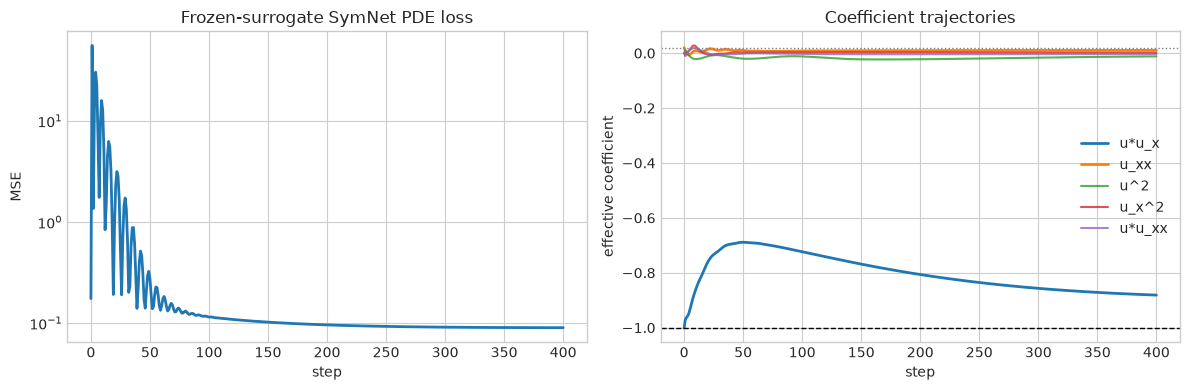

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(symnet_history_df["step"], symnet_history_df["pde_loss"], linewidth=2)
axes[0].set_title("Frozen-surrogate SymNet PDE loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")

axes[1].plot(symnet_history_df["step"], symnet_history_df["u*u_x"], label="u*u_x", linewidth=2)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u_xx"], label="u_xx", linewidth=2)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u^2"], label="u^2", alpha=0.8)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u_x^2"], label="u_x^2", alpha=0.8)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u*u_xx"], label="u*u_xx", alpha=0.8)
axes[1].axhline(-1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.02, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Coefficient trajectories")
axes[1].set_xlabel("step")
axes[1].set_ylabel("effective coefficient")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(symnet_history_df.tail())

## 8. Optional Next Experiment: Joint SIREN + SymNet Training

Question answered here: if we start from the same exact Burgers SymNet initialization but now let both the surrogate and SymNet move, how do the data loss, PDE loss, derivative fidelity, Burgers coefficients, and weight drift compare against the frozen-surrogate case above?

This section is intentionally off by default so it does not obscure the simpler experiments.

In [14]:
RUN_OPTIONAL_JOINT = False
joint_steps = 300
joint_batch_size = 4096
joint_lr = 5e-4
joint_lambda_pde = 1.0
joint_log_every = 50

if RUN_OPTIONAL_JOINT:
    joint_siren = copy.deepcopy(siren).to(device)
    joint_symnet = MinimalSymNet().to(device)
    initialize_symnet_to_burgers(joint_symnet, diffusion=NU_TRUE)

    joint_optimizer = torch.optim.Adam(
        list(joint_siren.parameters()) + list(joint_symnet.parameters()),
        lr=joint_lr,
    )
    joint_history = []

    for step in range(joint_steps + 1):
        idx = torch.randint(0, len(t_train), (joint_batch_size,), device=device)
        t_batch = t_train[idx].clone().detach().requires_grad_(True)
        x_batch = x_train[idx].clone().detach().requires_grad_(True)
        u_batch_true = u_train[idx]

        u_batch_pred = joint_siren(t_batch, x_batch)
        ut_batch = torch.autograd.grad(
            u_batch_pred,
            t_batch,
            grad_outputs=torch.ones_like(u_batch_pred),
            create_graph=True,
            retain_graph=True,
        )[0]
        ux_batch = torch.autograd.grad(
            u_batch_pred,
            x_batch,
            grad_outputs=torch.ones_like(u_batch_pred),
            create_graph=True,
            retain_graph=True,
        )[0]
        uxx_batch = torch.autograd.grad(
            ux_batch,
            x_batch,
            grad_outputs=torch.ones_like(ux_batch),
            create_graph=True,
            retain_graph=True,
        )[0]

        feat_batch = torch.cat([u_batch_pred, ux_batch, uxx_batch], dim=1)
        rhs_batch = joint_symnet(feat_batch)

        data_loss = loss_fn(u_batch_pred, u_batch_true)
        pde_loss = loss_fn(ut_batch, rhs_batch)
        total_loss = data_loss + joint_lambda_pde * pde_loss

        if step % joint_log_every == 0:
            full_fields = evaluate_model_and_derivatives_in_chunks(
                joint_siren,
                t_flat=t_flat,
                x_flat=x_flat,
                grid_shape=u_grid.shape,
                chunk_size=4096,
                device=device,
            )
            coeffs = product_term_dict(joint_symnet)
            joint_history.append({
                "step": step,
                "data_loss": float(data_loss.item()),
                "pde_loss": float(pde_loss.item()),
                "u_rel_l2": compute_error_metrics(full_fields["u"], u_grid)["rel_l2"],
                "ut_rel_l2": compute_error_metrics(full_fields["u_t"], reference["u_t"]["physical"])["rel_l2"],
                "ux_rel_l2": compute_error_metrics(full_fields["u_x"], reference["u_x"]["physical"])["rel_l2"],
                "uxx_rel_l2": compute_error_metrics(full_fields["u_xx"], reference["u_xx"]["physical"])["rel_l2"],
                "u*u_x": coeffs["u*u_x"],
                "u_xx": coeffs["u_xx"],
                "u^2": coeffs["u^2"],
                "u_x^2": coeffs["u_x^2"],
            })
            print(
                f"joint step {step:4d} | data_loss = {float(data_loss.item()):.6e} | "
                f"pde_loss = {float(pde_loss.item()):.6e} | c(u*u_x) = {coeffs['u*u_x']:+.6f} | c(u_xx) = {coeffs['u_xx']:+.6f}"
            )

        if step == joint_steps:
            break

        joint_optimizer.zero_grad()
        total_loss.backward()
        joint_optimizer.step()

    joint_history_df = pd.DataFrame(joint_history)
    display(joint_history_df)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(joint_history_df["step"], joint_history_df["data_loss"], label="data_loss")
    axes[0].plot(joint_history_df["step"], joint_history_df["pde_loss"], label="pde_loss")
    axes[0].set_yscale("log")
    axes[0].set_title("Joint losses")
    axes[0].legend(loc="best")

    axes[1].plot(joint_history_df["step"], joint_history_df["u*u_x"], label="u*u_x")
    axes[1].plot(joint_history_df["step"], joint_history_df["u_xx"], label="u_xx")
    axes[1].plot(joint_history_df["step"], joint_history_df["u^2"], label="u^2")
    axes[1].plot(joint_history_df["step"], joint_history_df["u_x^2"], label="u_x^2")
    axes[1].set_title("Joint coefficient drift")
    axes[1].legend(loc="best")

    axes[2].plot(joint_history_df["step"], joint_history_df["u_rel_l2"], label="u")
    axes[2].plot(joint_history_df["step"], joint_history_df["ut_rel_l2"], label="u_t")
    axes[2].plot(joint_history_df["step"], joint_history_df["ux_rel_l2"], label="u_x")
    axes[2].plot(joint_history_df["step"], joint_history_df["uxx_rel_l2"], label="u_xx")
    axes[2].set_title("Derivative fidelity during joint training")
    axes[2].legend(loc="best")

    plt.tight_layout()
    plt.show()
else:
    print("Optional joint experiment skipped. Set RUN_OPTIONAL_JOINT = True to execute it.")

Optional joint experiment skipped. Set RUN_OPTIONAL_JOINT = True to execute it.


## 9. Randomly Initialized SymNet, Frozen Surrogate

Question answered here: keeping the surrogate fixed, can the same minimal SymNet architecture find Burgers from ordinary random initialization when it is trained only against the frozen surrogate derivative field?

In [15]:
torch.manual_seed(SEED)
random_frozen_epochs = 1000
random_frozen_lr = 1e-2
random_frozen_checkpoints = sorted({0, 100, 500, 1000, random_frozen_epochs})
random_frozen_loss_fn = nn.MSELoss()

random_frozen_symnet = MinimalSymNet().to(device)
initial_random_frozen_coeffs = product_term_dict(random_frozen_symnet)
initial_random_frozen_pde_mse = float(
    random_frozen_loss_fn(random_frozen_symnet(frozen_feature_tensor), frozen_ut_target).item()
)

print("initial SymNet effective equation:")
print(pretty_equation(initial_random_frozen_coeffs))
print(f"initial PDE MSE = {initial_random_frozen_pde_mse:.6e}")
display(pd.DataFrame([initial_random_frozen_coeffs]).T.rename(columns={0: "initial_coefficient"}))

random_frozen_optimizer = torch.optim.Adam(random_frozen_symnet.parameters(), lr=random_frozen_lr)
random_frozen_loss_history = []
random_frozen_coeff_history = []

for epoch in range(random_frozen_epochs + 1):
    pred_ut = random_frozen_symnet(frozen_feature_tensor)
    pde_loss = random_frozen_loss_fn(pred_ut, frozen_ut_target)

    random_frozen_loss_history.append({
        "epoch": epoch,
        "pde_loss": float(pde_loss.item()),
    })

    if epoch in random_frozen_checkpoints:
        coeffs = product_term_dict(random_frozen_symnet)
        coeff_row = {"epoch": epoch, "pde_loss": float(pde_loss.item())}
        coeff_row.update(coeffs)
        random_frozen_coeff_history.append(coeff_row)
        print(f"epoch {epoch:4d} | raw PDE MSE = {float(pde_loss.item()):.6e}")
        print(pretty_equation(coeffs))

    if epoch == random_frozen_epochs:
        break

    random_frozen_optimizer.zero_grad()
    pde_loss.backward()
    random_frozen_optimizer.step()

random_frozen_loss_df = pd.DataFrame(random_frozen_loss_history)
random_frozen_coeff_df = pd.DataFrame(random_frozen_coeff_history)
final_random_frozen_coeffs = product_term_dict(random_frozen_symnet)
random_frozen_summary = {
    "optimizer": "Adam",
    "learning_rate": random_frozen_lr,
    "epochs": random_frozen_epochs,
    "initial_pde_mse": initial_random_frozen_pde_mse,
    "final_pde_mse": float(random_frozen_loss_df.iloc[-1]["pde_loss"]),
    "initial_equation": pretty_equation(initial_random_frozen_coeffs),
    "final_equation": pretty_equation(final_random_frozen_coeffs),
    "final_uux_coeff": float(final_random_frozen_coeffs["u*u_x"]),
    "final_uxx_coeff": float(final_random_frozen_coeffs["u_xx"]),
    "hand_init_final_pde_mse": float(symnet_history_df.iloc[-1]["pde_loss"]),
    "hand_init_final_uux_coeff": float(symnet_history_df.iloc[-1]["u*u_x"]),
    "hand_init_final_uxx_coeff": float(symnet_history_df.iloc[-1]["u_xx"]),
}

display(random_frozen_coeff_df)
print("initial equation:")
print(random_frozen_summary["initial_equation"])
print("final equation:")
print(random_frozen_summary["final_equation"])
print(f"recovered coeff(u*u_x) = {random_frozen_summary['final_uux_coeff']:+.6f} (truth -1.000000)")
print(f"recovered coeff(u_xx)  = {random_frozen_summary['final_uxx_coeff']:+.6f} (truth +0.020000)")
print(f"final PDE MSE = {random_frozen_summary['final_pde_mse']:.6e}")
print()
print("comparison to the hand-initialized frozen-surrogate run:")
print(f"hand-init final PDE MSE = {random_frozen_summary['hand_init_final_pde_mse']:.6e}")
print(f"hand-init final coeff(u*u_x) = {random_frozen_summary['hand_init_final_uux_coeff']:+.6f}")
print(f"hand-init final coeff(u_xx)  = {random_frozen_summary['hand_init_final_uxx_coeff']:+.6f}")


initial SymNet effective equation:
u_t_hat = (-0.011439)*u + (+0.457775)*u_x + (-0.051236)*u_xx + (+0.000486)*u^2 + (-0.034568)*u*u_x + (+0.053249)*u*u_xx + (-0.018224)*u_x^2 + (+0.040649)*u_x*u_xx + (-0.019467)*u_xx^2
initial PDE MSE = 2.064857e+05
epoch    0 | raw PDE MSE = 2.064857e+05
u_t_hat = (-0.011439)*u + (+0.457775)*u_x + (-0.051236)*u_xx + (+0.000486)*u^2 + (-0.034568)*u*u_x + (+0.053249)*u*u_xx + (-0.018224)*u_x^2 + (+0.040649)*u_x*u_xx + (-0.019467)*u_xx^2
epoch  100 | raw PDE MSE = 1.900342e+01
u_t_hat = (-0.021286)*u + (+0.296798)*u_x + (+0.056132)*u_xx + (+0.004213)*u^2 + (-0.004107)*u*u_x + (+0.008244)*u*u_xx + (-0.001365)*u_x^2 + (+0.001991)*u_x*u_xx + (+0.000218)*u_xx^2
epoch  500 | raw PDE MSE = 1.112197e+00
u_t_hat = (-0.136236)*u + (+0.256814)*u_x + (+0.002197)*u_xx + (+0.004264)*u^2 + (-0.005177)*u*u_x + (+0.008234)*u*u_xx + (-0.000094)*u_x^2 + (+0.000122)*u_x*u_xx + (+0.000038)*u_xx^2
epoch 1000 | raw PDE MSE = 9.651142e-01
u_t_hat = (-0.166766)*u + (+0.163397)*

,initial_coefficient
u,-0.011439
u_x,0.457775
u_xx,-0.051236
u^2,0.000486
u*u_x,-0.034568
u*u_xx,0.053249
u_x^2,-0.018224
u_x*u_xx,0.040649
u_xx^2,-0.019467


,epoch,pde_loss,u,u_x,u_xx,u^2,u*u_x,u*u_xx,u_x^2,u_x*u_xx,u_xx^2
0,0,206485.718750,-0.011439,0.457775,-0.051236,0.000486,-0.034568,0.053249,-0.018224,0.040649,-0.019467
1,100,19.003422,-0.021286,0.296798,0.056132,0.004213,-0.004107,0.008244,-0.001365,0.001991,0.000218
2,500,1.112197,-0.136236,0.256814,0.002197,0.004264,-0.005177,0.008234,-0.000094,0.000122,0.000038
3,1000,0.965114,-0.166766,0.163397,-0.001735,0.004231,-0.005406,0.008171,0.000067,-0.000123,0.000032


,epoch,pde_loss,u,u_x,u_xx,u^2,u*u_x,u*u_xx,u_x^2,u_x*u_xx,u_xx^2
0,0,206485.718750,-0.011439,0.457775,-0.051236,0.000486,-0.034568,0.053249,-0.018224,0.040649,-0.019467
1,100,19.003422,-0.021286,0.296798,0.056132,0.004213,-0.004107,0.008244,-0.001365,0.001991,0.000218
2,500,1.112197,-0.136236,0.256814,0.002197,0.004264,-0.005177,0.008234,-0.000094,0.000122,0.000038
3,1000,0.965114,-0.166766,0.163397,-0.001735,0.004231,-0.005406,0.008171,0.000067,-0.000123,0.000032


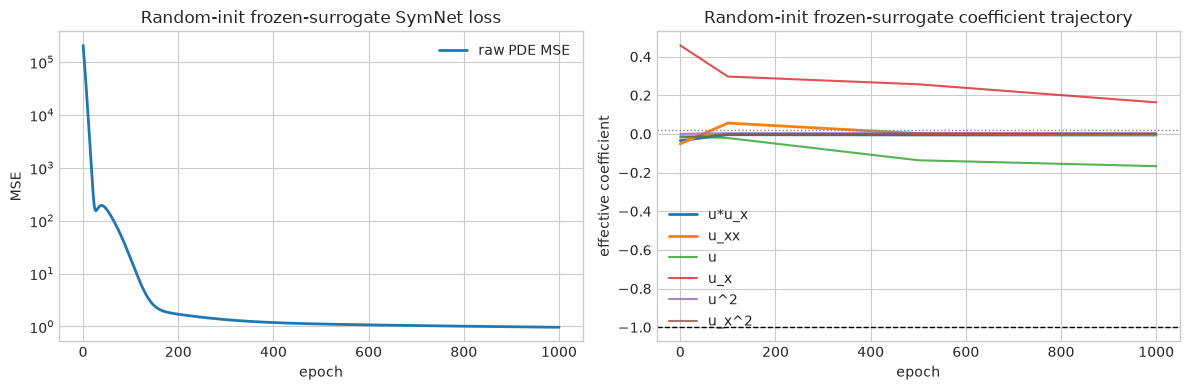

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(random_frozen_loss_df["epoch"], random_frozen_loss_df["pde_loss"], label="raw PDE MSE", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Random-init frozen-surrogate SymNet loss")
axes[0].legend(loc="best")

axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u*u_x"], label="u*u_x", linewidth=2)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u_xx"], label="u_xx", linewidth=2)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u"], label="u", alpha=0.8)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u_x"], label="u_x", alpha=0.8)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u^2"], label="u^2", alpha=0.8)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u_x^2"], label="u_x^2", alpha=0.8)
axes[1].axhline(-1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.02, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("effective coefficient")
axes[1].set_title("Random-init frozen-surrogate coefficient trajectory")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(random_frozen_coeff_df[["epoch", "pde_loss", "u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]])


### Section 9 Interpretation

- Did random initialization converge to the same basin as the hand-initialized run? No. On September 3, 2026, the random-init frozen-surrogate run converged to a different basin dominated by linear `u` and `u_x` terms instead of the Burgers `u*u_x` plus `u_xx` structure.
- Did it reach a similarly low PDE loss? No. Its final PDE MSE was about `9.65e-01`, versus about `8.996e-02` for the hand-initialized frozen-surrogate run.
- Did it recover the same support? No. The final effective equation retained large spurious linear terms and drove `u*u_x` and `u_xx` close to zero rather than isolating the Burgers support.
- Did it recover approximately correct Burgers coefficients? No. The final coefficients were `coeff(u*u_x) = -0.005406` and `coeff(u_xx) = -0.001735`, far from `-1.0` and `+0.02`.
- Did it settle into a different low-loss equation? Yes. The frozen surrogate admits a non-Burgers equation with lower loss than the random start but clearly not the Burgers basin, so this section is best described as case B: lower loss with wrong coefficients and wrong support.

## 10. Randomly Initialized SymNet + Joint SIREN/SymNet Training

Question answered here: once both the surrogate and the minimal SymNet start from ordinary initialization and are allowed to adapt together, does low data loss plus low internal PDE loss also correspond to correct derivatives and the Burgers equation?

In [17]:
torch.manual_seed(SEED)
lam_data = 1.0
lam_pde = 0.5
random_joint_epochs = 1000
random_joint_batch_size = 4096
random_joint_lr = 5e-4
random_joint_checkpoints = sorted({0, 100, 500, 1000, random_joint_epochs})
random_joint_loss_fn = nn.MSELoss()

random_joint_siren = SirenMLP(
    hidden_size=64,
    hidden_layers=3,
    first_omega_0=20.0,
    hidden_omega_0=1.0,
).to(device)
random_joint_symnet = MinimalSymNet().to(device)

with torch.no_grad():
    initial_random_joint_data_mse = float(random_joint_loss_fn(random_joint_siren(t_train, x_train), u_train).item())

t_init = t_train[:random_joint_batch_size].clone().detach().requires_grad_(True)
x_init = x_train[:random_joint_batch_size].clone().detach().requires_grad_(True)
u_init = random_joint_siren(t_init, x_init)
ut_init = torch.autograd.grad(u_init, t_init, grad_outputs=torch.ones_like(u_init), create_graph=False, retain_graph=True)[0]
ux_init = torch.autograd.grad(u_init, x_init, grad_outputs=torch.ones_like(u_init), create_graph=True, retain_graph=True)[0]
uxx_init = torch.autograd.grad(ux_init, x_init, grad_outputs=torch.ones_like(ux_init), create_graph=False, retain_graph=False)[0]
initial_random_joint_pde_mse = float(
    random_joint_loss_fn(ut_init, random_joint_symnet(torch.cat([u_init.detach(), ux_init.detach(), uxx_init.detach()], dim=1))).item()
)
initial_random_joint_coeffs = product_term_dict(random_joint_symnet)

print(f"initial data MSE = {initial_random_joint_data_mse:.6e}")
print(f"initial raw PDE MSE = {initial_random_joint_pde_mse:.6e}")
print("initial SymNet effective equation:")
print(pretty_equation(initial_random_joint_coeffs))
display(pd.DataFrame([initial_random_joint_coeffs]).T.rename(columns={0: "initial_coefficient"}))

random_joint_optimizer = torch.optim.Adam(
    list(random_joint_siren.parameters()) + list(random_joint_symnet.parameters()),
    lr=random_joint_lr,
)

random_joint_loss_history = []
random_joint_coeff_history = []

for epoch in range(random_joint_epochs + 1):
    idx = torch.randint(0, len(t_train), (random_joint_batch_size,), device=device)
    t_batch = t_train[idx].clone().detach().requires_grad_(True)
    x_batch = x_train[idx].clone().detach().requires_grad_(True)
    u_batch_true = u_train[idx]

    u_batch_pred = random_joint_siren(t_batch, x_batch)
    ut_batch = torch.autograd.grad(u_batch_pred, t_batch, grad_outputs=torch.ones_like(u_batch_pred), create_graph=True, retain_graph=True)[0]
    ux_batch = torch.autograd.grad(u_batch_pred, x_batch, grad_outputs=torch.ones_like(u_batch_pred), create_graph=True, retain_graph=True)[0]
    uxx_batch = torch.autograd.grad(ux_batch, x_batch, grad_outputs=torch.ones_like(ux_batch), create_graph=True, retain_graph=True)[0]
    rhs_batch = random_joint_symnet(torch.cat([u_batch_pred, ux_batch, uxx_batch], dim=1))

    data_loss = random_joint_loss_fn(u_batch_pred, u_batch_true)
    pde_loss = random_joint_loss_fn(ut_batch, rhs_batch)
    total_loss = lam_data * data_loss + lam_pde * pde_loss

    random_joint_loss_history.append({
        "epoch": epoch,
        "data_loss": float(data_loss.item()),
        "pde_loss": float(pde_loss.item()),
        "total_loss": float(total_loss.item()),
    })

    if epoch in random_joint_checkpoints:
        coeffs = product_term_dict(random_joint_symnet)
        coeff_row = {
            "epoch": epoch,
            "data_loss": float(data_loss.item()),
            "pde_loss": float(pde_loss.item()),
            "total_loss": float(total_loss.item()),
        }
        coeff_row.update(coeffs)
        random_joint_coeff_history.append(coeff_row)
        print(
            f"epoch {epoch:4d} | data MSE = {float(data_loss.item()):.6e} | "
            f"raw PDE MSE = {float(pde_loss.item()):.6e} | total loss = {float(total_loss.item()):.6e}"
        )
        print(pretty_equation(coeffs))

    if epoch == random_joint_epochs:
        break

    random_joint_optimizer.zero_grad()
    total_loss.backward()
    random_joint_optimizer.step()

random_joint_loss_df = pd.DataFrame(random_joint_loss_history)
random_joint_coeff_df = pd.DataFrame(random_joint_coeff_history)
random_joint_fields = evaluate_model_and_derivatives_in_chunks(
    random_joint_siren,
    t_flat=t_flat,
    x_flat=x_flat,
    grid_shape=u_grid.shape,
    chunk_size=4096,
    device=device,
)
random_joint_solution_metrics = pd.DataFrame([
    as_metric_row("u", random_joint_fields["u"], u_grid),
]).set_index("quantity")
random_joint_derivative_metrics = pd.DataFrame([
    as_metric_row("u_t", random_joint_fields["u_t"], reference["u_t"]["physical"]),
    as_metric_row("u_x", random_joint_fields["u_x"], reference["u_x"]["physical"]),
    as_metric_row("u_xx", random_joint_fields["u_xx"], reference["u_xx"]["physical"]),
]).set_index("quantity")
final_random_joint_coeffs = product_term_dict(random_joint_symnet)
random_joint_summary = {
    "optimizer": "Adam",
    "learning_rate": random_joint_lr,
    "epochs": random_joint_epochs,
    "initial_data_mse": initial_random_joint_data_mse,
    "final_data_mse": float(random_joint_loss_df.iloc[-1]["data_loss"]),
    "initial_pde_mse": initial_random_joint_pde_mse,
    "final_pde_mse": float(random_joint_loss_df.iloc[-1]["pde_loss"]),
    "initial_equation": pretty_equation(initial_random_joint_coeffs),
    "final_equation": pretty_equation(final_random_joint_coeffs),
    "final_uux_coeff": float(final_random_joint_coeffs["u*u_x"]),
    "final_uxx_coeff": float(final_random_joint_coeffs["u_xx"]),
}

display(random_joint_solution_metrics)
display(random_joint_derivative_metrics)
display(random_joint_coeff_df)
print("initial equation:")
print(random_joint_summary["initial_equation"])
print("final equation:")
print(random_joint_summary["final_equation"])
print(f"recovered coeff(u*u_x) = {random_joint_summary['final_uux_coeff']:+.6f} (truth -1.000000)")
print(f"recovered coeff(u_xx)  = {random_joint_summary['final_uxx_coeff']:+.6f} (truth +0.020000)")


initial data MSE = 1.576198e+00
initial raw PDE MSE = 5.039675e+02
initial SymNet effective equation:
u_t_hat = (+0.125140)*u + (+0.389047)*u_x + (+0.295680)*u_xx + (+0.018618)*u^2 + (-0.127232)*u*u_x + (+0.001522)*u*u_xx + (-0.169741)*u_x^2 + (+0.020785)*u_x*u_xx + (-0.000405)*u_xx^2
epoch    0 | data MSE = 1.545579e+00 | raw PDE MSE = 7.817963e+02 | total loss = 3.924438e+02
u_t_hat = (+0.125140)*u + (+0.389047)*u_x + (+0.295680)*u_xx + (+0.018618)*u^2 + (-0.127232)*u*u_x + (+0.001522)*u*u_xx + (-0.169741)*u_x^2 + (+0.020785)*u_x*u_xx + (-0.000405)*u_xx^2
epoch  100 | data MSE = 8.303983e-01 | raw PDE MSE = 1.410925e+01 | total loss = 7.885023e+00
u_t_hat = (+0.150256)*u + (+0.372236)*u_x + (+0.276068)*u_xx + (+0.011342)*u^2 + (-0.126442)*u*u_x + (-0.000786)*u*u_xx + (-0.160852)*u_x^2 + (+0.014565)*u_x*u_xx + (-0.000037)*u_xx^2
epoch  500 | data MSE = 6.086199e-01 | raw PDE MSE = 1.190176e+00 | total loss = 1.203708e+00
u_t_hat = (+0.167894)*u + (+0.373548)*u_x + (+0.267987)*u_xx + (

,initial_coefficient
u,0.125140
u_x,0.389047
u_xx,0.295680
u^2,0.018618
u*u_x,-0.127232
u*u_xx,0.001522
u_x^2,-0.169741
u_x*u_xx,0.020785
u_xx^2,-0.000405


,mse,rel_l2,rmse,max_abs
quantity,,,,
u,0.454098,0.78672,0.673868,1.289135


,mse,rel_l2,rmse,max_abs
quantity,,,,
u_t,1.231943,1.137749,1.109929,6.666527
u_x,5.179158,0.973172,2.275776,28.807596
u_xx,2581.011465,1.001009,50.803656,757.577672


,epoch,data_loss,pde_loss,total_loss,u,u_x,u_xx,u^2,u*u_x,u*u_xx,u_x^2,u_x*u_xx,u_xx^2
0,0,1.545579,781.796326,392.443756,0.125140,0.389047,0.295680,0.018618,-0.127232,0.001522,-0.169741,0.020785,-0.000405
1,100,0.830398,14.109249,7.885023,0.150256,0.372236,0.276068,0.011342,-0.126442,-0.000786,-0.160852,0.014565,-0.000037
2,500,0.608620,1.190176,1.203708,0.167894,0.373548,0.267987,0.009464,-0.130099,-0.000368,-0.161040,0.014939,-0.000060
3,1000,0.450415,0.365075,0.632953,0.173554,0.373709,0.264648,0.009119,-0.130912,-0.000314,-0.161011,0.014971,-0.000061


,epoch,data_loss,pde_loss,total_loss,u,u_x,u_xx,u^2,u*u_x,u*u_xx,u_x^2,u_x*u_xx,u_xx^2
0,0,1.545579,781.796326,392.443756,0.125140,0.389047,0.295680,0.018618,-0.127232,0.001522,-0.169741,0.020785,-0.000405
1,100,0.830398,14.109249,7.885023,0.150256,0.372236,0.276068,0.011342,-0.126442,-0.000786,-0.160852,0.014565,-0.000037
2,500,0.608620,1.190176,1.203708,0.167894,0.373548,0.267987,0.009464,-0.130099,-0.000368,-0.161040,0.014939,-0.000060
3,1000,0.450415,0.365075,0.632953,0.173554,0.373709,0.264648,0.009119,-0.130912,-0.000314,-0.161011,0.014971,-0.000061


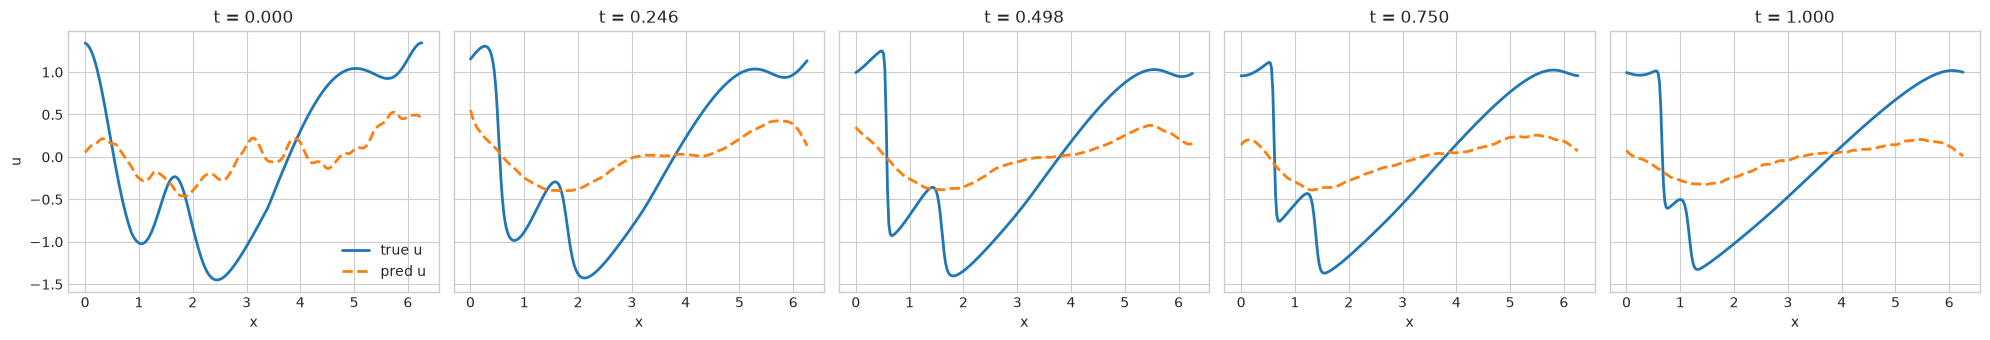

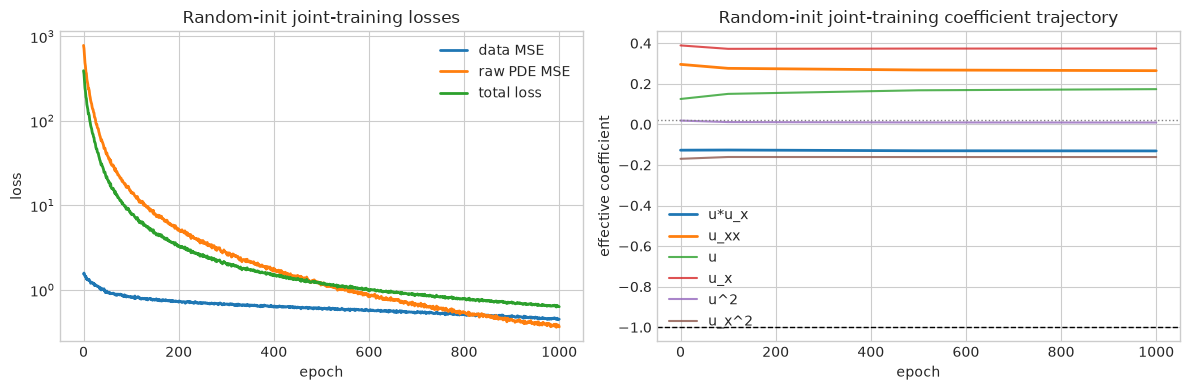

In [18]:
plot_time_slices(
    x_grid,
    u_grid,
    pred_grid=random_joint_fields["u"],
    time_values=t_grid,
    title_prefix="u",
    slice_indices=slice_indices,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(random_joint_loss_df["epoch"], random_joint_loss_df["data_loss"], label="data MSE", linewidth=2)
axes[0].plot(random_joint_loss_df["epoch"], random_joint_loss_df["pde_loss"], label="raw PDE MSE", linewidth=2)
axes[0].plot(random_joint_loss_df["epoch"], random_joint_loss_df["total_loss"], label="total loss", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Random-init joint-training losses")
axes[0].legend(loc="best")

axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u*u_x"], label="u*u_x", linewidth=2)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u_xx"], label="u_xx", linewidth=2)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u"], label="u", alpha=0.8)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u_x"], label="u_x", alpha=0.8)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u^2"], label="u^2", alpha=0.8)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u_x^2"], label="u_x^2", alpha=0.8)
axes[1].axhline(-1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.02, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("effective coefficient")
axes[1].set_title("Random-init joint-training coefficient trajectory")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(random_joint_coeff_df[["epoch", "data_loss", "pde_loss", "total_loss", "u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]])


### Section 10 Interpretation

- Compare Section 10 against Section 8: Section 8 showed that the architecture can represent Burgers and that the Burgers basin is stable when initialized there, ending near `coeff(u*u_x) = -0.881262`, `coeff(u_xx) = +0.010047`, and PDE MSE about `8.996e-02`. Section 10 did not return to that basin from random initialization.
- Compare Section 10 against Section 9: Section 10 achieved lower internal PDE loss than the frozen-surrogate random-init run (`3.651e-01` versus `9.651e-01`), but it still converged to the wrong support and wrong coefficients, with `u*u_x` stuck near `-0.130912` and `u_xx` near `+0.264648`.
- Did low internal PDE loss coincide with good derivatives and Burgers recovery? No. Even with data MSE reduced to about `4.50e-01` and PDE MSE reduced to about `3.65e-01`, the final derivative errors remained poor: relative L2 was about `1.14` for `u_t`, `0.97` for `u_x`, and `1.00` for `u_xx`, and the discovered equation was still far from Burgers.
- Is there evidence of SIREN/SymNet co-adaptation? Yes. Compared with Section 9, allowing the surrogate to move reduced the internal PDE loss further without recovering the correct PDE or correct derivatives, which is consistent with co-adaptation toward an internally easier but physically wrong explanation.
- Overall diagnosis: Section 10 is best interpreted as case B. The end-to-end system finds a lower-loss internal agreement than the frozen-surrogate random-init run, but that lower loss does not correspond to correct Burgers recovery.

## 11. Direct Coefficient-Space Control

The previous experiments show that the minimal SymNet can represent the Burgers equation, but random initialization does not recover it even with the surrogate frozen. This leaves two possibilities: the difficulty may lie in optimizing SymNet's internal parameters into the correct PDE coefficients, or the frozen surrogate derivatives may themselves favor a non-Burgers equation.

To separate these effects, bypass the SymNet parameterization and fit the same candidate PDE terms directly by least squares,

`u_t ≈ Theta xi`.

Here least squares searches directly over `xi`, whereas SymNet + Adam searches over internal weights `theta` that indirectly generate `xi(theta)`. The final prediction is still `u_t_hat = Theta xi`, but this control removes the nonlinear `theta -> xi` map.

In [19]:
ls_feature_names = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
ls_feature_arrays = {
    "u": surrogate_fields["u"].reshape(-1),
    "u_x": surrogate_fields["u_x"].reshape(-1),
    "u_xx": surrogate_fields["u_xx"].reshape(-1),
}
ls_feature_arrays["u^2"] = ls_feature_arrays["u"] ** 2
ls_feature_arrays["u*u_x"] = ls_feature_arrays["u"] * ls_feature_arrays["u_x"]
ls_feature_arrays["u*u_xx"] = ls_feature_arrays["u"] * ls_feature_arrays["u_xx"]
ls_feature_arrays["u_x^2"] = ls_feature_arrays["u_x"] ** 2
ls_feature_arrays["u_x*u_xx"] = ls_feature_arrays["u_x"] * ls_feature_arrays["u_xx"]
ls_feature_arrays["u_xx^2"] = ls_feature_arrays["u_xx"] ** 2

theta_direct = np.column_stack([ls_feature_arrays[name] for name in ls_feature_names])
y_direct = surrogate_fields["u_t"].reshape(-1)
direct_coeffs, direct_residuals, direct_rank, direct_singular_vals = np.linalg.lstsq(theta_direct, y_direct, rcond=None)
direct_coeff_dict = {name: float(value) for name, value in zip(ls_feature_names, direct_coeffs)}
direct_ut_hat = theta_direct @ direct_coeffs
direct_pde_mse = float(np.mean((y_direct - direct_ut_hat) ** 2))

def pretty_linear_equation(coeff_dict, ordered_names):
    terms = [f"({coeff_dict[name]:+.6f})*{name}" for name in ordered_names]
    return "u_t_hat = " + " + ".join(terms)

direct_ls_summary = {
    "method": "direct least squares",
    "pde_mse": direct_pde_mse,
    "u*u_x": direct_coeff_dict["u*u_x"],
    "u_xx": direct_coeff_dict["u_xx"],
    "equation": pretty_linear_equation(direct_coeff_dict, ls_feature_names),
}

print("phase-9 frozen surrogate reused: yes")
print("candidate library reused: full 9-term degree-2 expansion of MinimalSymNet")
print(f"rank(Theta) = {direct_rank}")
print(f"singular values = {direct_singular_vals}")
print()
print("Direct least-squares recovered PDE:")
print(direct_ls_summary["equation"])
print()
print("All nine coefficients:")
display(pd.DataFrame([direct_coeff_dict]).T.rename(columns={0: "coefficient"}))
print(f"coeff(u*u_x) vs true -1.000000: {direct_ls_summary['u*u_x']:+.6f} | error = {direct_ls_summary['u*u_x'] + 1.0:+.6e}")
print(f"coeff(u_xx)  vs true +0.020000: {direct_ls_summary['u_xx']:+.6f} | error = {direct_ls_summary['u_xx'] - 0.02:+.6e}")
print(f"PDE MSE on the frozen-surrogate comparison points = {direct_ls_summary['pde_mse']:.6e}")

phase11_comparison_df = pd.DataFrame([
    {
        "experiment": "hand-initialized frozen SymNet",
        "PDE MSE": float(symnet_history_df.iloc[-1]["pde_loss"]),
        "coeff(u*u_x)": float(symnet_history_df.iloc[-1]["u*u_x"]),
        "coeff(u_xx)": float(symnet_history_df.iloc[-1]["u_xx"]),
    },
    {
        "experiment": "random-initialized frozen SymNet",
        "PDE MSE": float(random_frozen_summary["final_pde_mse"]),
        "coeff(u*u_x)": float(random_frozen_summary["final_uux_coeff"]),
        "coeff(u_xx)": float(random_frozen_summary["final_uxx_coeff"]),
    },
    {
        "experiment": "direct least squares",
        "PDE MSE": direct_ls_summary["pde_mse"],
        "coeff(u*u_x)": direct_ls_summary["u*u_x"],
        "coeff(u_xx)": direct_ls_summary["u_xx"],
    },
])
display(phase11_comparison_df)


phase-9 frozen surrogate reused: yes
candidate library reused: full 9-term degree-2 expansion of MinimalSymNet
rank(Theta) = 9
singular values = [5.9335560e+06 1.8776408e+05 1.0214019e+04 6.3995151e+03 4.6394316e+03
 3.2321191e+02 2.3124373e+02 2.1920988e+02 1.8382745e+02]

Direct least-squares recovered PDE:
u_t_hat = (-0.026607)*u + (+0.031648)*u_x + (+0.009980)*u_xx + (-0.004855)*u^2 + (-0.892455)*u*u_x + (-0.002124)*u*u_xx + (+0.000004)*u_x^2 + (-0.000616)*u_x*u_xx + (+0.000001)*u_xx^2

All nine coefficients:
coeff(u*u_x) vs true -1.000000: -0.892455 | error = +1.075449e-01
coeff(u_xx)  vs true +0.020000: +0.009980 | error = -1.002040e-02
PDE MSE on the frozen-surrogate comparison points = 8.851884e-02


,coefficient
u,-0.026607
u_x,0.031648
u_xx,0.009980
u^2,-0.004855
u*u_x,-0.892455
u*u_xx,-0.002124
u_x^2,0.000004
u_x*u_xx,-0.000616
u_xx^2,0.000001


,experiment,PDE MSE,coeff(u*u_x),coeff(u_xx)
0,hand-initialized frozen SymNet,0.089954,-0.881262,0.010047
1,random-initialized frozen SymNet,0.965114,-0.005406,-0.001735
2,direct least squares,0.088519,-0.892455,0.009980


### Section 11 Interpretation

- On September 3, 2026, direct least squares on the exact frozen Phase 9 derivative field recovered a coefficient vector very close to the hand-initialized frozen-SymNet basin: `coeff(u*u_x) = -0.892455`, `coeff(u_xx) = +0.009980`, and PDE MSE `8.851884e-02`.
- That is far closer to Burgers than the random-initialized frozen-SymNet run, which ended at `coeff(u*u_x) = -0.005406`, `coeff(u_xx) = -0.001735`, and PDE MSE `9.651142e-01`.
- The evidence therefore points primarily to the `theta -> xi` side of the pipeline: the frozen surrogate derivatives contain enough information to recover a much more Burgers-like coefficient vector directly in `xi`, while Adam from random SymNet initialization fails to reach that basin through the nonlinear parameterization.
- This is still not exact Burgers recovery, so the frozen derivative field is imperfect; but the dominant gap exposed by this control is not direct coefficient identifiability.